In [62]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import scipy.stats

url = "airbnb_data.csv"
df = pd.read_csv(url)

/var/folders/cc/k2w3n13x3sndt6mbgq0813c40000gp/T/ipykernel_3912/3390119977.py:5: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [65]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

id                                  int64
NAME                               object
host id                             int64
host_identity_verified             object
host name                          object
neighbourhood group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country code                       object
instant_bookable                   object
cancellation_policy                object
room type                          object
Construction year                 float64
price                              object
service fee                        object
minimum nights                    float64
number of reviews                 float64
last review                        object
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

In [ ]:
# For numeric columns print out the mean, median, and standard deviation of each column
summary = df.select_dtypes(include="number").agg(['mean', 'median', 'std'])
print(summary)

                  id       host id        lat       long  Construction year  \
mean    2.914623e+07  4.925411e+10  40.728094 -73.949644        2012.487464   
median  2.913660e+07  4.911774e+10  40.722290 -73.954440        2012.000000   
std     1.625751e+07  2.853900e+10   0.055857   0.049521           5.765556   

        minimum nights  number of reviews  reviews per month  \
mean          8.135845          27.483743           1.374022   
median        3.000000           7.000000           0.740000   
std          30.553781          49.508954           1.746621   

        review rate number  calculated host listings count  availability 365  
mean              3.279106                        7.936605        141.133254  
median            3.000000                        1.000000         96.000000  
std               1.284657                       32.218780        135.435024  


In [88]:
#For categorical columns print out the number of unique values and the names of each unique value if it has less than 10 uniqe values.

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    vals = df[col].dropna().unique()
    if len(vals) < 10:
        print(f"{vals}")
        print(f"{col}: {len(vals)} unique values")

['unconfirmed' 'verified']
host_identity_verified: 2 unique values
['Brooklyn' 'Manhattan' 'brookln' 'manhatan' 'Queens' 'Staten Island'
 'Bronx']
neighbourhood group: 7 unique values
['United States']
country: 1 unique values
['US']
country code: 1 unique values
[False True]
instant_bookable: 2 unique values
['strict' 'moderate' 'flexible']
cancellation_policy: 3 unique values
['Private room' 'Entire home/apt' 'Shared room' 'Hotel room']
room type: 4 unique values
['41662/AL']
license: 1 unique values


In [68]:
#how many nullish values are in each column 
#Checking for "neighbourhood"

df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [69]:
#standard deviation of review rate number

df["review rate number"].std()

1.2846569239029912

In [70]:
#skewness of number of reviews
import scipy 
scipy.stats.skew(df["number of reviews"].dropna())

np.float64(3.8393399827193573)

In [71]:
#kurtosis of number of reviews

scipy.stats.kurtosis(df["number of reviews"].dropna())

np.float64(25.02858164593076)

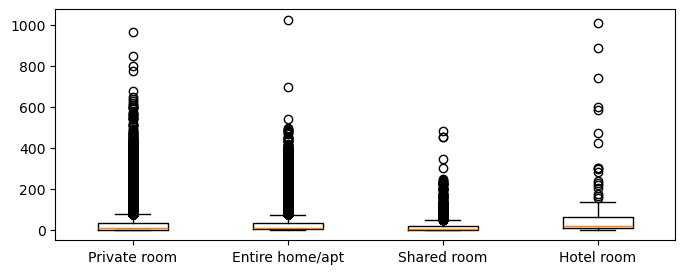

In [80]:
#Boxplot of number of reviews by room type

plt.figure(figsize=[8,3])
pos = df["room type"].unique()
df1 = df.dropna(subset=["number of reviews"])
data_list = [df1.loc[df1["room type"] == p, "number of reviews"] for p in pos]
plt.boxplot(data_list)
plt.xticks(ticks=range(1,len(pos)+1), labels = pos)
plt.show()

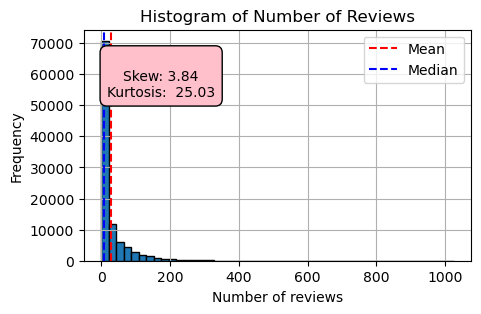

In [73]:
#Histogram of number of reviews

data = df["number of reviews"].dropna()
plt.figure(figsize=(5,3))
bins = round(data.count() ** (1/3))
plt.hist(x=data, bins=bins, edgecolor = "black")
plt.xlabel("Number of reviews")
plt.ylabel("Frequency")
ymax = 100
xmax = 25
plt.title("Histogram of Number of Reviews")
sk = scipy.stats.skew(data)
kurt = scipy.stats.kurtosis(data)
string = f"""
Skew: {sk:.2f}
Kurtosis: {kurt: .2f}"""
# plt.text(x=12.5, y=50, s=string, ha="left", va = "bottom")
plt.text(
    x=.20,
    y=.80,
    s=string,
    ha="center",
    va = "center",
    #bbox=dict(boxstyle= "round, pad=0.5", fc = "white"),
    bbox={"boxstyle": "round, pad=0.5", "fc": "pink"},
    transform = plt.gca().transAxes)
plt.axvline(x=data.mean(), color="r", linestyle = "--", label = "Mean")
plt.axvline(x=data.median(), color="b", linestyle = "--", label = "Median")
plt.grid()
plt.legend()
plt.show()

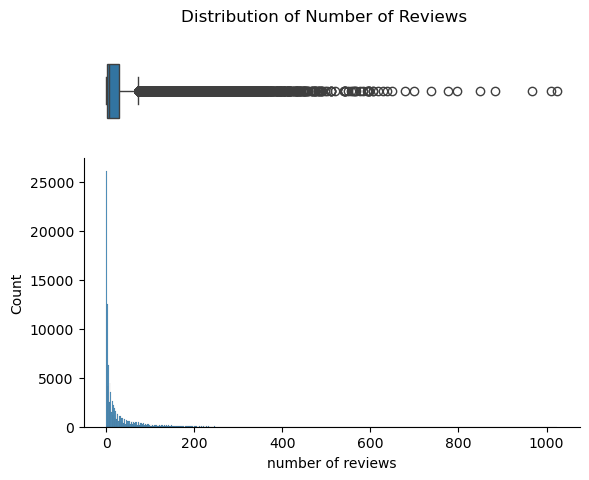

In [74]:
#multiplot of number of reviews

def multiplot(df: pd.DataFrame, col: str, xlabel=str):
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, height_ratios=[2,8])
    box = sns.boxplot(data=df, x=col, ax=ax1)
    hist = sns.histplot(data=df, x=col, ax=ax2)
    box.set(xlabel="", xticks=[], yticks=[])
    ax1.spines["bottom"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    hist.set(xlabel=xlabel)
    plt.suptitle("Distribution of Number of Reviews")
    plt.show()

multiplot(df=df, col="number of reviews", xlabel="number of reviews")